# Sentiment Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from textblob import TextBlob
from wordcloud import WordCloud

# Load Dataset

In [7]:
sentiment_dataset = pd.read_csv("3) sentiment dataset.csv")
sentiment_dataset.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


# Text Preprocessing

In [10]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

sentiment_dataset['clean_text'] = sentiment_dataset['Text'].apply(clean_text)

# Tokenization (Split Text into Words)

In [11]:
sentiment_dataset['tokens'] = sentiment_dataset['clean_text'].apply(lambda x: x.split())

# Sentiment Analysis Using TextBlob

In [12]:
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity == 0:
        return "Neutral"
    else:
        return "Negative"

sentiment_dataset['predicted_sentiment'] = sentiment_dataset['clean_text'].apply(get_sentiment)

# Visualize Sentiment Distribution

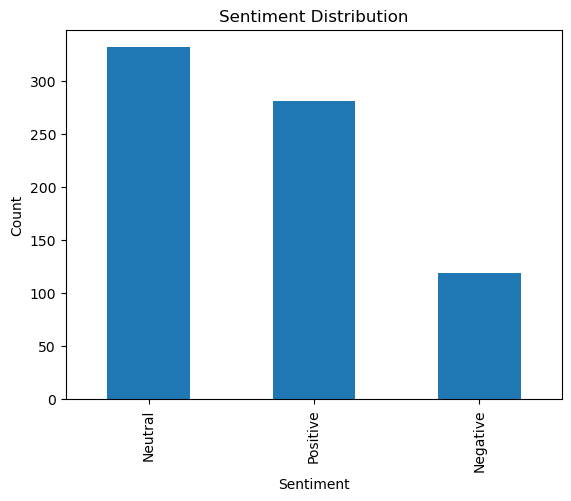

In [13]:
# We count how many Positive, Negative, Neutral
sentiment_dataset['predicted_sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Word Cloud (Most Frequent Words)

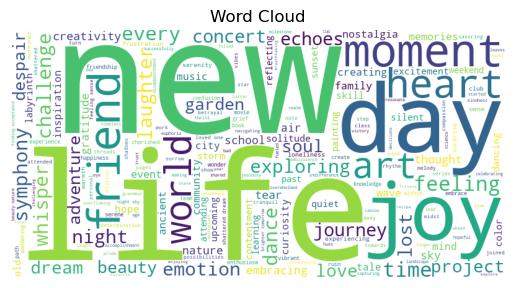

In [14]:
# This shows the most common words
text = " ".join(sentiment_dataset['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()


# Word Frequency

In [16]:
from collections import Counter

all_words = " ".join(sentiment_dataset['clean_text']).split()
word_freq = Counter(all_words)

print(word_freq.most_common(10))

[('new', 43), ('like', 27), ('day', 26), ('feeling', 26), ('dreams', 25), ('laughter', 24), ('heart', 24), ('night', 23), ('joy', 23), ('life', 22)]
